# 02 Baseline Experiment

Note: The pristine baseline is evaluated as part of the robustness evaluation matrix. This notebook provides a standalone clean-data experiment for convenience.

In [25]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from IPython.display import display

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.preprocessing import load_dataset
from src.models import get_models
from src.config import N_SPLITS, RANDOM_STATE
from src.metrics import calculate_metrics

X, y, feature_names, lb, _ = load_dataset()

[SUCCESS] Loaded Dataset: 1014 records[cite: 1].


In [26]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_results = []
confusion_matrices = {}

print("Starting Baseline Evaluation...")
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Processing Fold {fold + 1}/{N_SPLITS}...")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_test_df = pd.DataFrame(X_test, columns=feature_names)
    y_test_bin = lb.transform(y_test)
    
    # Reinitialize models for each fold
    models = get_models(random_state=RANDOM_STATE)
    
    for name, model in models.items():
        if name not in confusion_matrices:
            confusion_matrices[name] = np.zeros((3, 3), dtype=int)
            
        model.fit(X_train_df, y_train)
        y_pred = model.predict(X_test_df)
        y_prob = model.predict_proba(X_test_df)
        
        acc, macro_f1, high_risk_recall, brier = calculate_metrics(y_test, y_pred, y_prob, y_test_bin)
        
        cv_results.append({
            "Fold": fold + 1,
            "Classifier": name,
            "Accuracy": acc,
            "Macro F1": macro_f1,
            "High Risk Recall": high_risk_recall,
            "Brier Score": brier
        })
        
        confusion_matrices[name] += confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

print("Evaluation Complete.")

Starting Baseline Evaluation...
Processing Fold 1/5...
Processing Fold 2/5...
Processing Fold 3/5...
Processing Fold 4/5...
Processing Fold 5/5...
Evaluation Complete.


In [27]:
baseline_df = pd.DataFrame(cv_results)
baseline_summary = baseline_df.groupby("Classifier")[["Accuracy", "Macro F1", "High Risk Recall", "Brier Score"]].agg(["mean", "std"])

formatted_summary = pd.DataFrame()
for col in ["Accuracy", "Macro F1", "High Risk Recall", "Brier Score"]:
    formatted_summary[col] = baseline_summary[col].apply(
        lambda row: f"{row['mean']:.4f} ± {row['std']:.4f}", axis=1
    )

display(formatted_summary)

,Accuracy,Macro F1,High Risk Recall,Brier Score
Classifier,,,,
Logistic Regression,0.6173 ± 0.0348,0.6046 ± 0.0362,0.7168 ± 0.0435,0.4779 ± 0.0269
Random Forest,0.8511 ± 0.0199,0.8561 ± 0.0189,0.9081 ± 0.0343,0.2172 ± 0.0378
Support Vector Machine,0.7002 ± 0.0325,0.6902 ± 0.0411,0.8345 ± 0.0472,0.4205 ± 0.0364
XGBoost,0.8541 ± 0.0309,0.8586 ± 0.0302,0.9116 ± 0.0493,0.2113 ± 0.0505


In [28]:
import os
os.makedirs("../results", exist_ok=True)
baseline_df.to_csv("../results/baseline_results.csv", index=False)
print("Saved results to ../results/baseline_results.csv")

Saved results to ../results/baseline_results.csv


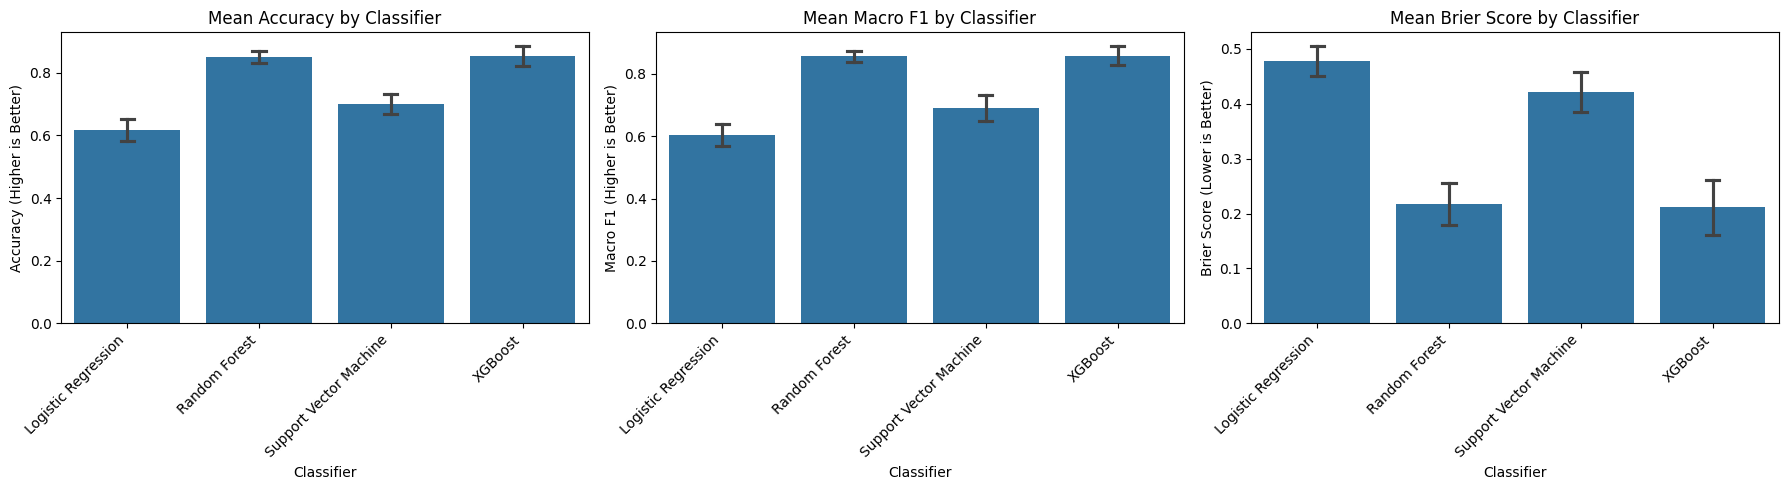

In [29]:
metrics = ["Accuracy", "Macro F1", "Brier Score"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    sns.barplot(data=baseline_df, x="Classifier", y=metric, ax=axes[i], capsize=0.1, errorbar='sd')
    axes[i].set_title(f"Mean {metric} by Classifier")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    if metric == "Brier Score":
        axes[i].set_ylabel(f"{metric} (Lower is Better)")
    else:
        axes[i].set_ylabel(f"{metric} (Higher is Better)")

plt.tight_layout()
plt.show()

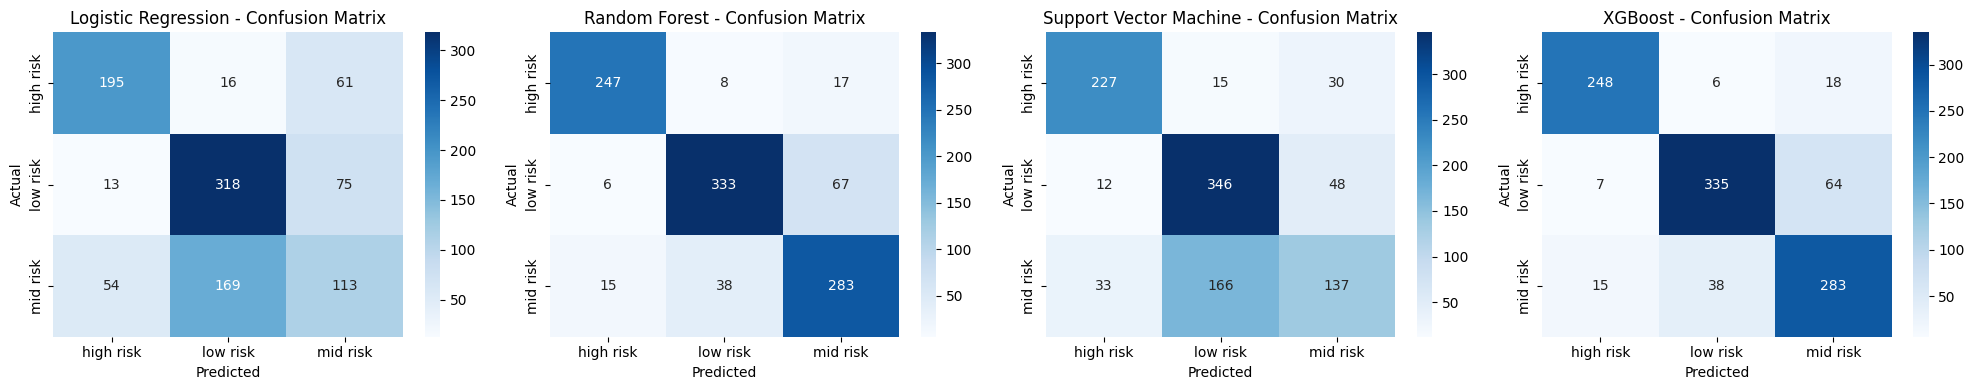

In [30]:
classes = ['high risk', 'low risk', 'mid risk']

fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(5 * len(confusion_matrices), 4))
if len(confusion_matrices) == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()